# Term Project: Smoke and Fire Detection using YOLO
## Phase 1: Environment Setup & Exploratory Data Analysis (EDA)

In this first phase, we lay the groundwork for our deep learning pipeline. The objectives are:
1. **Environment Setup:** Programmatically configure our YOLO `data.yaml` file to use absolute local paths to avoid directory resolution errors during training.
2. **Data Integrity Check:** Verify that every image in our dataset has a corresponding YOLO label file. Missing labels can cause dataloader crashes or force the model to treat images with actual fires as negative (background) samples.
3. **Class Distribution Analysis:** Analyze the balance between the 'Smoke' and 'Fire' classes across our Train, Validation, and Test splits.
4. **Bounding Box Scale Analysis:** Analyze the dimensions (width and height) of the bounding boxes. This is a critical EDA step for object detection, as it informs us about the scale of the objects the model needs to detect (e.g., small distant fires vs. large screen-filling smoke).

In [ ]:
# import os
# from pathlib import Path

# download_root = Path("/mnt/d/Programming Lesson/DL DataSet")
# download_root.mkdir(parents=True, exist_ok=True)
# os.environ["KAGGLEHUB_CACHE"] = str(download_root)

# import kagglehub

# path = kagglehub.dataset_download("sayedgamal99/smoke-fire-detection-yolo")
# print("Dataset downloaded to:", path)

In [19]:
import os
import yaml
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for the notebook
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Define base paths
base_path = "/mnt/d/Programming Lesson/DL DataSet/datasets/sayedgamal99/smoke-fire-detection-yolo/versions/1"
data_yaml_path = os.path.join(base_path, "data.yaml")
project_yaml_path = os.path.join(base_path, "project_data.yaml") # We will create a new one to keep the original safe

### 1.1 Updating the YOLO Configuration File
YOLO requires a `.yaml` file that dictates where the training, validation, and testing images are located. We will read the original configuration, update the paths to be absolute, and save it as `project_data.yaml`.

In [20]:
# Read the original YAML
with open(data_yaml_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

# Update paths to be absolute
config['path'] = base_path
config['train'] = "data/train/images"
config['val'] = "data/val/images"
config['test'] = "data/test/images"

# Save the updated config specifically for this project
with open(project_yaml_path, "w", encoding="utf-8") as f:
    yaml.dump(config, f, sort_keys=False)

print(f"✅ Updated configuration saved to: {project_yaml_path}")
print("Config contents:")
print(yaml.dump(config, sort_keys=False))

# Extract class names for later use
class_names = config['names']
print(f"Detected Classes: {class_names}")

✅ Updated configuration saved to: /mnt/d/Programming Lesson/DL DataSet/datasets/sayedgamal99/smoke-fire-detection-yolo/versions/1/project_data.yaml
Config contents:
path: /mnt/d/Programming Lesson/DL DataSet/datasets/sayedgamal99/smoke-fire-detection-yolo/versions/1
train: data/train/images
val: data/val/images
test: data/test/images
names:
- smoke
- fire
nc: 2
train_count: 14122
val_count: 3099
test_count: 4306

Detected Classes: ['smoke', 'fire']


### 1.2 Data Integrity Check
We must ensure the structural integrity of the dataset. For every `.jpg` or `.png` in the `images` folder, there should be a corresponding `.txt` file in the `labels` folder. Note: YOLO allows empty `.txt` files (or completely missing `.txt` files in newer versions) to represent background images with no objects, but it's good practice to verify the structure.

In [21]:
subsets = ["train", "val", "test"]
integrity_results = []

for subset in subsets:
    img_dir = os.path.join(base_path, "data", subset, "images")
    lbl_dir = os.path.join(base_path, "data", subset, "labels")
    
    # Get all file stems (filenames without extensions)
    images = [os.path.splitext(f)[0] for f in os.listdir(img_dir) if f.endswith((".jpg", ".png", ".jpeg"))]
    labels = [os.path.splitext(f)[0] for f in os.listdir(lbl_dir) if f.endswith(".txt")]
    
    img_set = set(images)
    lbl_set = set(labels)
    
    missing_labels = img_set - lbl_set
    missing_images = lbl_set - img_set
    
    integrity_results.append({
        "Split": subset.capitalize(),
        "Images": len(img_set),
        "Labels": len(lbl_set),
        "Missing Labels (Backgrounds)": len(missing_labels),
        "Orphaned Labels": len(missing_images)
    })

integrity_df = pd.DataFrame(integrity_results)
display(integrity_df)

if integrity_df['Orphaned Labels'].sum() == 0:
    print("✅ Dataset integrity is perfect. No orphaned labels found.")
else:
    print("⚠️ Warning: Orphaned labels found (labels without images). YOLO will ignore them, but it indicates dirty data.")

,Split,Images,Labels,Missing Labels (Backgrounds),Orphaned Labels
0,Train,14122,14122,0,0
1,Val,3099,3099,0,0
2,Test,4306,4306,0,0


✅ Dataset integrity is perfect. No orphaned labels found.


### 1.3 Class Distribution Analysis
Next, we parse through every single label `.txt` file to count how many instances of 'Smoke' and 'Fire' exist. This will tell us if our dataset suffers from severe class imbalance, which might require us to use techniques like Focal Loss or class weighting during Phase 4 (Training).

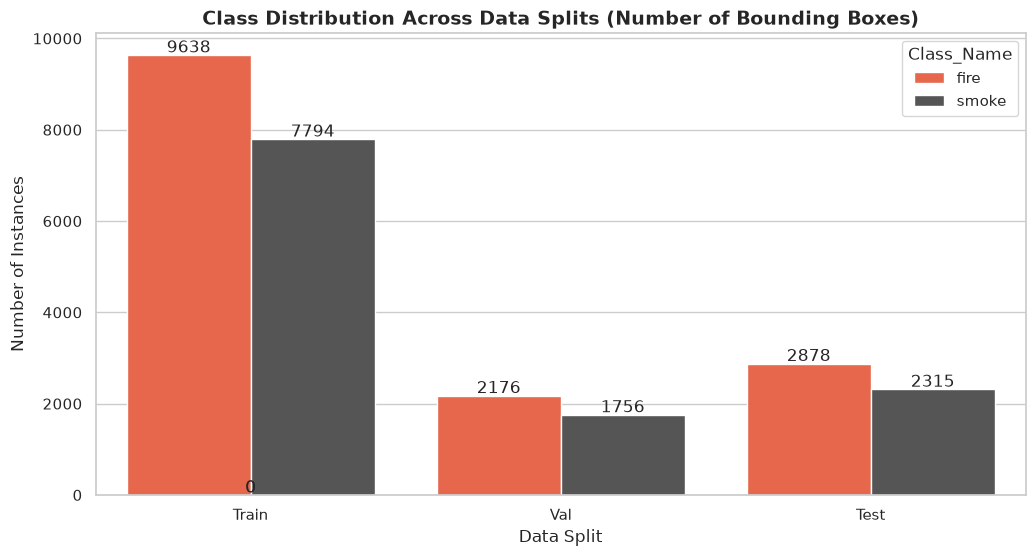

In [25]:
bbox_data = []

# Parse all label files to extract class and bounding box data
for subset in subsets:
    lbl_dir = os.path.join(base_path, "data", subset, "labels")
    label_files = glob.glob(os.path.join(lbl_dir, "*.txt"))
    
    for file in label_files:
        with open(file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:])
                    bbox_data.append({
                        "Split": subset.capitalize(),
                        "Class_ID": cls_id,
                        "Class_Name": class_names[cls_id],
                        "Width": width,
                        "Height": height,
                        "Area": width * height
                    })

df_bboxes = pd.DataFrame(bbox_data)

# Plot Class Distribution
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_bboxes, x='Split', hue='Class_Name', palette=['#FF5733', '#555555'])
plt.title('Class Distribution Across Data Splits (Number of Bounding Boxes)', fontsize=14, fontweight='bold')
plt.xlabel('Data Split', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)

# Add counts above bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

### 1.4 Bounding Box Scale Analysis (Scale & Aspect Ratio)
Finally, we analyze the normalized dimensions of our bounding boxes. YOLO represents bounding box coordinates normalized between 0 and 1. 
* By plotting `Width` vs `Height`, we can see if our objects are generally small, large, tall, or wide. 
* If all boxes are concentrated in the lower-left corner, the model needs to be highly sensitive to small objects.

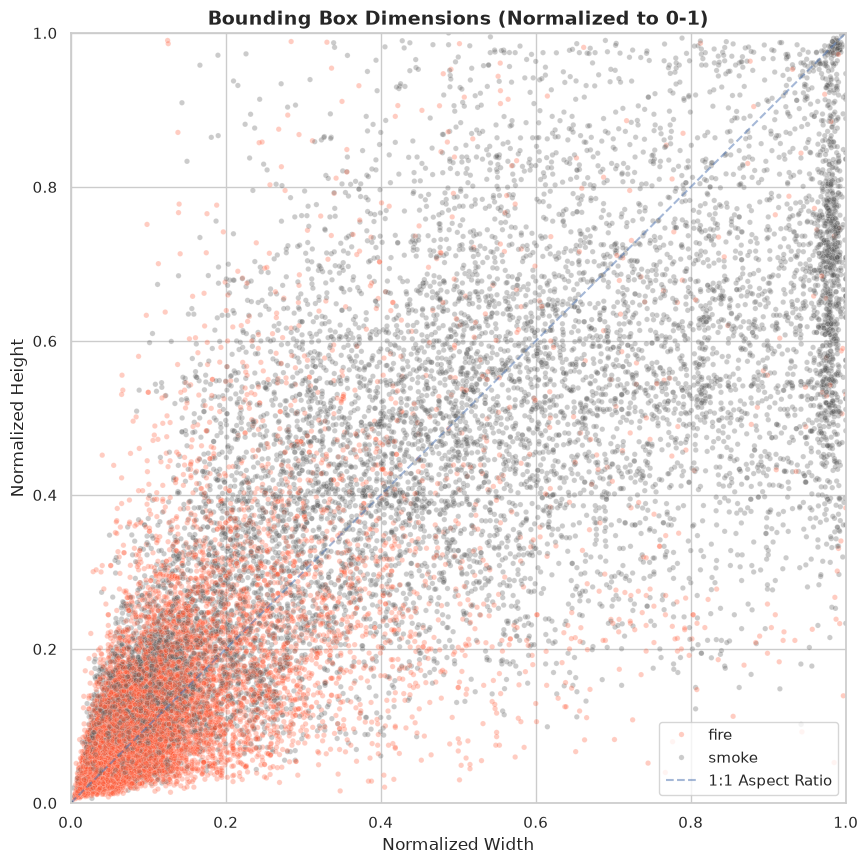

Bounding Box Area Statistics (% of image size):


,count,mean,std,min,25%,50%,75%,max
Class_Name,,,,,,,,
fire,1469200.0,2.4,6.2,0.0,0.2,0.5,1.8,96.3
smoke,1186500.0,22.6,24.1,0.0,1.6,14.2,37.8,100.0


In [24]:
# Plot Bounding Box Size Distribution (Scatter Plot)
plt.figure(figsize=(10, 10))
sns.scatterplot(data=df_bboxes, x='Width', y='Height', hue='Class_Name', alpha=0.3, s=15, palette=['#FF5733', '#555555'])

# Plot diagonal line representing a perfect square (1:1 aspect ratio)
plt.plot([0, 1], [0, 1], 'b--', alpha=0.5, label='1:1 Aspect Ratio')

plt.title('Bounding Box Dimensions (Normalized to 0-1)', fontsize=14, fontweight='bold')
plt.xlabel('Normalized Width', fontsize=12)
plt.ylabel('Normalized Height', fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.show()

# Quick summary statistics on Bounding Box Area
print("Bounding Box Area Statistics (% of image size):")
display(df_bboxes.groupby('Class_Name')['Area'].describe().round(3) * 100)

### 1.5 Visual Data Exploration (Ground Truth Inspection)
Statistics only tell half the story. To truly understand our dataset, we must visualize the images and their annotations. 

In this section, we will:
1. **Visualize Positive Samples:** Plot random images that contain Fire and/or Smoke, overlaying the YOLO bounding boxes to verify that the annotations are tight and accurate.
2. **Visualize Negative (Background) Samples:** The dataset contains 9,838 "None" images. In YOLO, these are represented either by empty `.txt` files or images with no corresponding `.txt` file at all. We must visualize these to understand what the authors considered "background" (e.g., are they empty forests, urban scenes with red lights, or cloudy skies that look like smoke?).

Found 7664 positive training images.


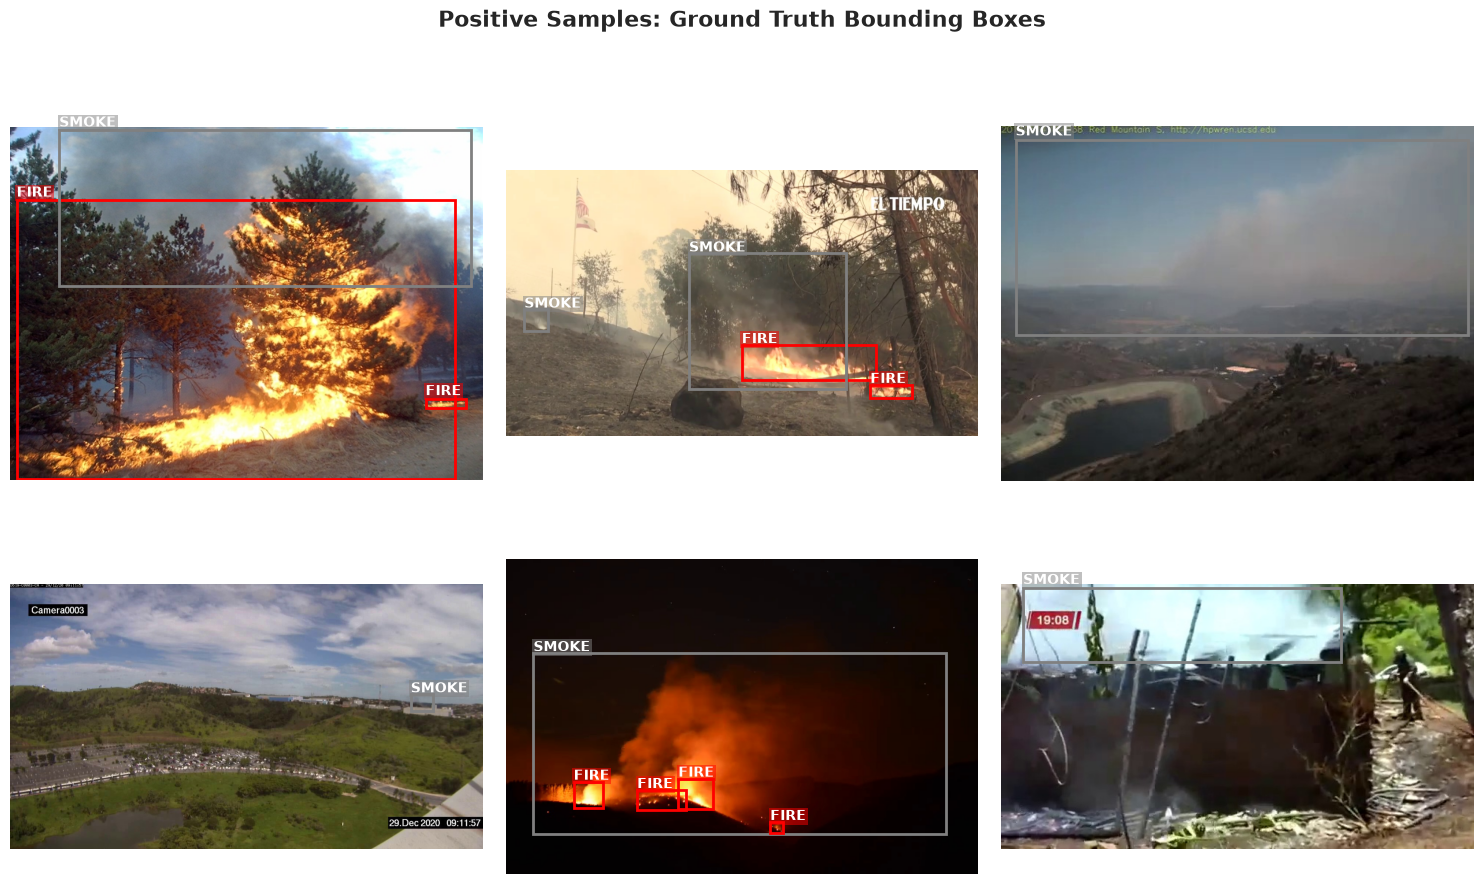

In [26]:
import cv2
import random
import matplotlib.patches as patches
from PIL import Image

def plot_yolo_images(image_paths, label_dir, class_names, title="Sample Images"):
    """
    Helper function to plot images with their YOLO bounding boxes.
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    axes = axes.flatten()

    for i, img_path in enumerate(image_paths):
        if i >= 6: break # Only plot 6 images
        
        # Load image
        img = Image.open(img_path)
        img_w, img_h = img.size
        
        ax = axes[i]
        ax.imshow(img)
        ax.axis('off')
        
        # Find corresponding label file
        filename = os.path.basename(img_path)
        basename = os.path.splitext(filename)[0]
        lbl_path = os.path.join(label_dir, f"{basename}.txt")
        
        # If label file exists, draw boxes
        if os.path.exists(lbl_path) and os.path.getsize(lbl_path) > 0:
            with open(lbl_path, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls_id = int(parts[0])
                        x_center, y_center, w, h = map(float, parts[1:])
                        
                        # Un-normalize YOLO coordinates to pixel coordinates
                        abs_w = w * img_w
                        abs_h = h * img_h
                        abs_x = (x_center * img_w) - (abs_w / 2)
                        abs_y = (y_center * img_h) - (abs_h / 2)
                        
                        # Choose color based on class
                        color = 'red' if class_names[cls_id] == 'fire' else 'gray'
                        
                        # Create and add bounding box patch
                        rect = patches.Rectangle((abs_x, abs_y), abs_w, abs_h, 
                                                 linewidth=2, edgecolor=color, facecolor='none')
                        ax.add_patch(rect)
                        
                        # Add text label
                        ax.text(abs_x, abs_y - 5, class_names[cls_id].upper(), 
                                color='white', fontsize=10, weight='bold', 
                                bbox=dict(facecolor=color, alpha=0.5, edgecolor='none', pad=1))
        else:
             ax.set_title("BACKGROUND (No Objects)", color='green', fontweight='bold')
             
    plt.tight_layout()
    plt.show()

# --- 1. Visualize Positive Samples (Images with labels) ---
train_img_dir = os.path.join(base_path, "data", "train", "images")
train_lbl_dir = os.path.join(base_path, "data", "train", "labels")

# Get list of images that HAVE non-empty label files
all_train_images = glob.glob(os.path.join(train_img_dir, "*.jpg"))
positive_images = []

for img_path in all_train_images:
    basename = os.path.splitext(os.path.basename(img_path))[0]
    lbl_path = os.path.join(train_lbl_dir, f"{basename}.txt")
    if os.path.exists(lbl_path) and os.path.getsize(lbl_path) > 0:
        positive_images.append(img_path)

print(f"Found {len(positive_images)} positive training images.")

# Select 6 random positive images
random_positives = random.sample(positive_images, min(6, len(positive_images)))
plot_yolo_images(random_positives, train_lbl_dir, class_names, title="Positive Samples: Ground Truth Bounding Boxes")

### 1.6 Background Image Inspection
In object detection, "background" images are just as important as the targets. If the model only ever sees fire and smoke, it will start predicting fire on anything bright and orange (like a sunset or streetlamp). 

By feeding YOLO empty images (images with no objects), we penalize the model for false positives. Let's look at the background images the dataset authors included to see if they are challenging "hard negatives" (e.g., fog, clouds, sunsets).

Found 6458 negative (background) training images.


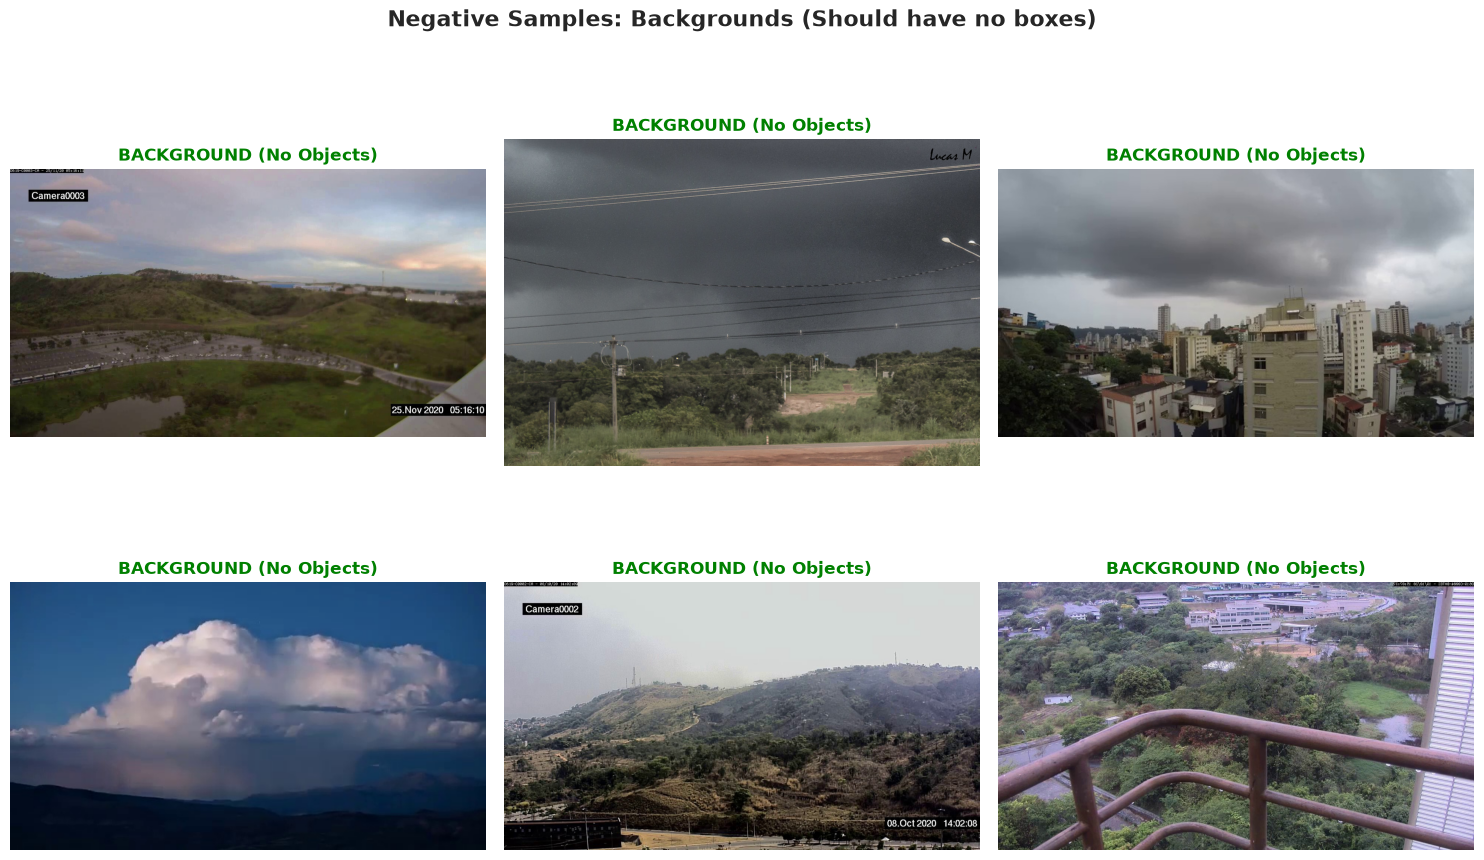

In [27]:
# --- 2. Visualize Negative (Background) Samples ---
negative_images = []

for img_path in all_train_images:
    basename = os.path.splitext(os.path.basename(img_path))[0]
    lbl_path = os.path.join(train_lbl_dir, f"{basename}.txt")
    # A negative image either has NO label file, or an EMPTY label file
    if not os.path.exists(lbl_path) or os.path.getsize(lbl_path) == 0:
        negative_images.append(img_path)

print(f"Found {len(negative_images)} negative (background) training images.")

if len(negative_images) > 0:
    # Select 6 random negative images
    random_negatives = random.sample(negative_images, min(6, len(negative_images)))
    plot_yolo_images(random_negatives, train_lbl_dir, class_names, title="Negative Samples: Backgrounds (Should have no boxes)")
else:
    print("No background images found in the training set.")

### 1.7 Dataset Split & Bounding Box Balance Analysis
To verify split parity and balance, we compare four key metrics across the `train`, `val`, and `test` splits:
1. **Total Images:** Overall image count in each split.
2. **Background Images:** Negative samples (images containing no fire or smoke instances) used to suppress false alarms.
3. **Fire Boxes:** Number of ground-truth annotations for the `fire` class.
4. **Smoke Boxes:** Number of ground-truth annotations for the `smoke` class.

This allows us to ensure that the ratio of target classes and background negatives is consistently distributed across all subsets.

,Total Images,Background Images,Fire Boxes,Smoke Boxes
Train,14122,6458,9638,7794
Val,3099,1375,2176,1756
Test,4306,2005,2878,2315


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


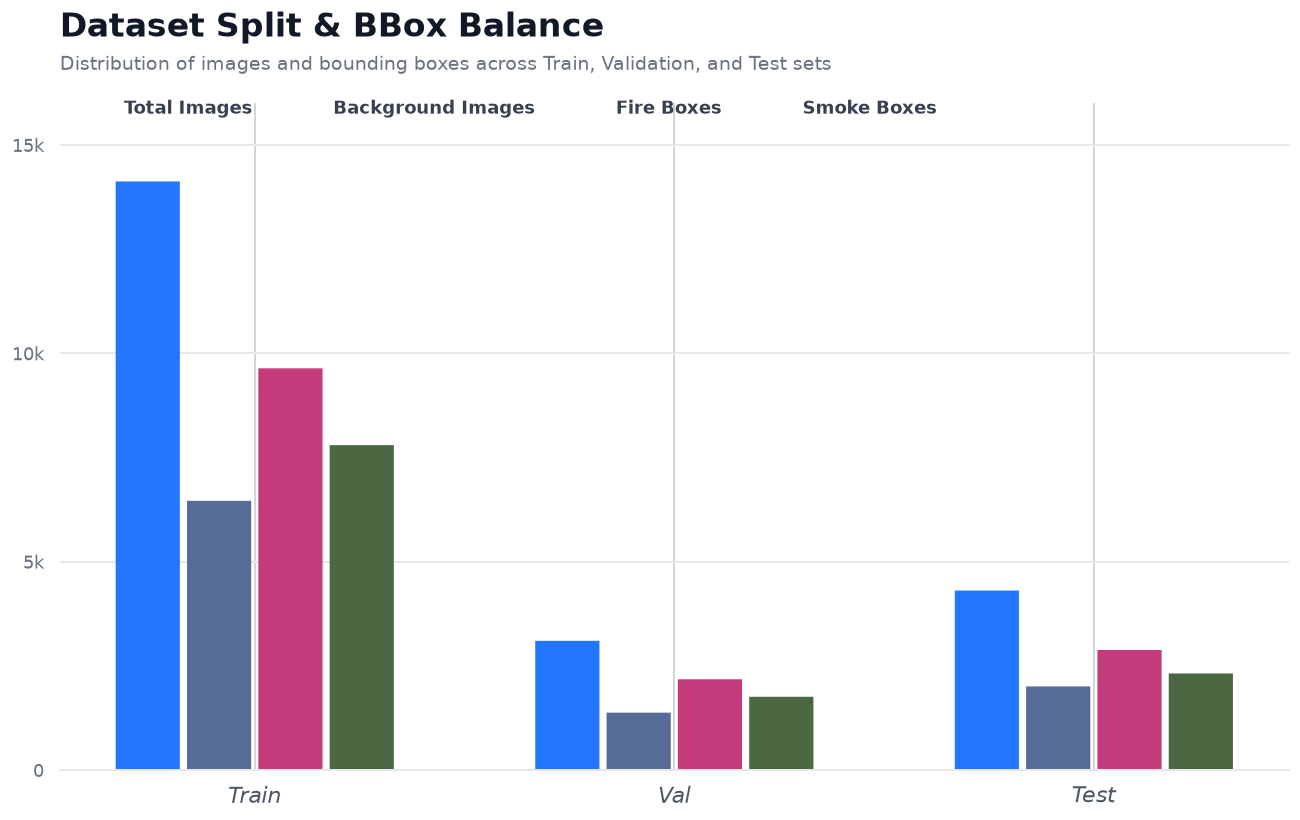

In [28]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# --- 1. Compute Exact Counts from Dataset Directory ---
splits = ['train', 'val', 'test']
categories = ['Total Images', 'Background Images', 'Fire Boxes', 'Smoke Boxes']

split_metrics = {cat: [] for cat in categories}

for s in splits:
    img_dir = os.path.join(base_path, "data", s, "images")
    lbl_dir = os.path.join(base_path, "data", s, "labels")
    
    # Supported image extensions
    img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    total_imgs = len(img_files)
    
    bg_imgs = 0
    fire_count = 0
    smoke_count = 0
    
    for img_name in img_files:
        stem = os.path.splitext(img_name)[0]
        lbl_file = os.path.join(lbl_dir, f"{stem}.txt")
        
        # Check if negative/background image (no label file or empty file)
        if not os.path.exists(lbl_file) or os.path.getsize(lbl_file) == 0:
            bg_imgs += 1
        else:
            with open(lbl_file, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls_id = int(parts[0])
                        if cls_id == 0:     # Smoke
                            smoke_count += 1
                        elif cls_id == 1:   # Fire
                            fire_count += 1

    split_metrics['Total Images'].append(total_imgs)
    split_metrics['Background Images'].append(bg_imgs)
    split_metrics['Fire Boxes'].append(fire_count)
    split_metrics['Smoke Boxes'].append(smoke_count)

# Display tabular summary
summary_df = pd.DataFrame(split_metrics, index=['Train', 'Val', 'Test'])
display(summary_df)


# --- 2. Plot Grouped Bar Chart ---
colors = ['#2377ff', '#566b96', '#c33b7b', '#4b6842']
x = np.arange(len(splits))
width = 0.17  # Bar width

fig, ax = plt.subplots(figsize=(11, 7), dpi=120)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Plot each metric group
rects = []
for i, (metric, color) in enumerate(zip(categories, colors)):
    pos = x - (1.5 * width) + (i * width)
    rect = ax.bar(
        pos, 
        split_metrics[metric], 
        width=width * 0.90, 
        label=metric, 
        color=color, 
        edgecolor='none'
    )
    rects.append(rect)

# Apply rounded corners to bar tops
for group in rects:
    for bar in group:
        h = bar.get_height()
        w = bar.get_width()
        bx = bar.get_x()
        
        # Draw rounded patch over standard rectangle
        bb = FancyBboxPatch(
            (bx, 0), w, h,
            boxstyle=f"round,pad=0,rounding_size={w * 0.45}",
            mutation_scale=1,
            facecolor=bar.get_facecolor(),
            edgecolor="none",
            clip_on=False
        )
        bar.set_visible(False)
        ax.add_patch(bb)

# X-axis configuration
ax.set_xticks(x)
ax.set_xticklabels(['Train', 'Val', 'Test'], fontsize=13, fontstyle='italic', color='#4b5563')
ax.tick_params(axis='x', which='both', bottom=False)

# Y-axis configuration
max_val = max(max(v) for v in split_metrics.values())
y_max = int(np.ceil(max_val / 5000.0) * 5000)
ax.set_ylim(0, y_max + 1000)
y_ticks = np.arange(0, y_max + 1, 5000)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f"{int(y/1000)}k" if y > 0 else '0' for y in y_ticks], fontsize=11, color='#6b7280')

# Gridlines and spines
ax.yaxis.grid(True, linestyle='-', color='#e5e7eb', linewidth=1.2, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#e5e7eb')
ax.spines['bottom'].set_linewidth(1.2)

# Titles
plt.title(
    "Dataset Split & BBox Balance", 
    fontsize=20, 
    fontweight='bold', 
    color='#111827', 
    loc='left', 
    pad=40
)
plt.text(
    0.0, 1.05, 
    "Distribution of images and bounding boxes across Train, Validation, and Test sets", 
    fontsize=11.5, 
    color='#6b7280', 
    transform=ax.transAxes
)

# Pill-style Legend
legend = ax.legend(
    loc='upper left',
    bbox_to_anchor=(0.0, 1.03),
    ncol=4,
    frameon=False,
    fontsize=11,
    handletextpad=0.6,
    columnspacing=1.8
)
for text in legend.get_texts():
    text.set_color('#374151')
    text.set_weight('semibold')

plt.tight_layout()
plt.show()

# Phase 2: Data Preprocessing & Augmentation Strategy

YOLO models handle raw image resizing, pixel normalization (scaling 0-255 to 0.0-1.0), and tensor conversions automatically during the training dataloader phase. Therefore, our preprocessing step focuses on **configuring the augmentation pipeline**.

### Augmentation Rationale for Fire & Smoke:
Fire and smoke detection is highly susceptible to False Positives. If our augmentations are too aggressive, we ruin the physical context:
1. **Color Jitter (HSV):** We must be careful here. Shifting the Hue (H) too far might turn green leaves orange (confusing the model into thinking it's fire). We will use a moderate saturation (S) and value (V) shift to simulate different lighting conditions (day vs. night fires).
2. **Flipping:** We will allow **horizontal flips** (fire looks the same mirrored left-to-right), but we will **disable vertical flips** (fire and smoke always rise upwards due to gravity and thermal dynamics; upside-down fire is physically impossible and will confuse the model).
3. **Mosaic & MixUp:** YOLO's default Mosaic combines 4 images into 1. This is excellent for teaching the model scale variation and handling backgrounds. We will keep Mosaic enabled but tone down MixUp (blending images on top of each other), which can create ghost-like artifacts that ruin the distinct edges of smoke plumes.

We will define these custom hyperparameters and save them to a `custom_hyp.yaml` file, which we will pass to the YOLO trainer in Phase 3.

In [29]:
import yaml
import os

# Define the path where we will save our custom hyperparameter configuration
hyp_yaml_path = os.path.join(base_path, "custom_hyp.yaml")

# Define the custom augmentation hyperparameters tailored for Fire/Smoke
custom_hyperparameters = {
    # --- Optimization/Base Params ---
    'lr0': 0.01,           # initial learning rate (i.e. SGD=1E-2, Adam=1E-3)
    'lrf': 0.01,           # final OneCycleLR learning rate (lr0 * lrf)
    'momentum': 0.937,     # SGD momentum/Adam beta1
    'weight_decay': 0.0005,# optimizer weight decay
    'warmup_epochs': 3.0,  # warmup epochs (fractions ok)
    'warmup_momentum': 0.8,# warmup initial momentum
    'warmup_bias_lr': 0.1, # warmup initial bias lr
    
    # --- Box/Loss Weights ---
    'box': 7.5,            # box loss gain (YOLOv8 default)
    'cls': 0.5,            # cls loss gain (YOLOv8 default)
    'dfl': 1.5,            # dfl loss gain (YOLOv8 default)
    
    # --- Custom Fire/Smoke Augmentations ---
    'hsv_h': 0.015,        # image HSV-Hue augmentation (fraction). Keep LOW to preserve fire color.
    'hsv_s': 0.7,          # image HSV-Saturation augmentation (fraction). High to simulate vivid fire/faded smoke.
    'hsv_v': 0.4,          # image HSV-Value augmentation (fraction). Simulate day/night lighting.
    'degrees': 5.0,        # image rotation (+/- deg). Slight tilt is fine.
    'translate': 0.1,      # image translation (+/- fraction)
    'scale': 0.5,          # image scale (+/- gain)
    'shear': 0.0,          # image shear (+/- deg). Disabled.
    'perspective': 0.0,    # image perspective (+/- fraction), range 0-0.001. Disabled.
    
    # --- Physical Orientation Constraints ---
    'fliplr': 0.5,         # image flip left-right (probability). 50% chance is good.
    'flipud': 0.0,         # image flip up-down (probability). STRICTLY 0. Fire/smoke only goes up!
    
    # --- Mosaic & Mixup ---
    'mosaic': 1.0,         # image mosaic (probability). 100% is great for context.
    'mixup': 0.0,          # image mixup (probability). Disabled to avoid ghosting artifacts.
    'copy_paste': 0.0      # segment copy-paste (probability). Disabled.
}

# Save to YAML
with open(hyp_yaml_path, "w", encoding="utf-8") as f:
    yaml.dump(custom_hyperparameters, f, sort_keys=False)

print(f"✅ Custom augmentation hyperparameters saved to: {hyp_yaml_path}")

# Display the contents to verify
print("\n--- Current Augmentation Profile ---")
with open(hyp_yaml_path, 'r') as f:
    print(f.read())

✅ Custom augmentation hyperparameters saved to: /mnt/d/Programming Lesson/DL DataSet/datasets/sayedgamal99/smoke-fire-detection-yolo/versions/1/custom_hyp.yaml

--- Current Augmentation Profile ---
lr0: 0.01
lrf: 0.01
momentum: 0.937
weight_decay: 0.0005
warmup_epochs: 3.0
warmup_momentum: 0.8
warmup_bias_lr: 0.1
box: 7.5
cls: 0.5
dfl: 1.5
hsv_h: 0.015
hsv_s: 0.7
hsv_v: 0.4
degrees: 5.0
translate: 0.1
scale: 0.5
shear: 0.0
perspective: 0.0
fliplr: 0.5
flipud: 0.0
mosaic: 1.0
mixup: 0.0
copy_paste: 0.0



### 2.1 Defining the Input Resolution
The final preprocessing step before training is determining our image input size (`imgsz`). 

YOLO defaults to 640x640 pixels. Because our Phase 1 EDA showed that many fires and smoke plumes occupy a reasonable percentage of the image, `640` is a safe and efficient starting point. If our EDA had shown incredibly tiny fires (e.g., distant forest fires occupying < 1% of the image), we would need to scale up to `1280` to preserve pixel detail, at the cost of slower training and inference.

For this project, we will proceed with `imgsz=640`. The `ultralytics` package will automatically pad and letterbox the images to fit this square resolution while preserving the original aspect ratio, ensuring no distortion occurs.

# Phase 3: Model Selection & Baseline Training

### Pre-Trained vs. Training from Scratch
For this project, we will absolutely use a **pre-trained model** (Transfer Learning) rather than initializing weights from scratch. Here is why:
1. **Feature Extraction:** A pre-trained YOLO model (trained on the massive COCO dataset) already understands foundational visual concepts like edges, curves, shadows, and color gradients. 
2. **Data & Time Efficiency:** Training a complex neural network from scratch requires hundreds of thousands of images just to learn basic geometry. By starting with a pre-trained model, the network immediately focuses its learning capacity on the specific textures and colors of "fire" and "smoke", reaching higher accuracy in a fraction of the time (e.g., 50 epochs instead of 500).

### Why YOLO26s?
We are using **YOLO26s** (the "Small" variant of the January 2026 release). YOLO26 brings several architectural breakthroughs that make it ideal for fire detection:
* **NMS-Free Inference:** It utilizes a DFL-free dual-head architecture, eliminating the need for Non-Maximum Suppression (NMS) during inference. This dramatically reduces latency and integration errors when deployed to edge devices.
* **Speed:** Designed heavily for edge computing, YOLO26 delivers up to 43% faster CPU inference compared to YOLO11. 
* **Stable Convergence:** It introduces the **MuSGD** optimizer (a hybrid of SGD and Muon-inspired optimization) which prevents training instability and accelerates convergence.

In [31]:
from ultralytics import YOLO
import os

# --- 1. Initialize the YOLO26 Small Model ---
# This will automatically download the 'yolo26s.pt' pre-trained weights from Ultralytics
model = YOLO("yolo26s.pt")

# --- 2. Define Paths ---
# Ensure these match the absolute paths established in Phase 1
project_yaml_path = "/mnt/d/Programming Lesson/DL DataSet/datasets/sayedgamal99/smoke-fire-detection-yolo/versions/1/project_data.yaml"
hyp_yaml_path = "/mnt/d/Programming Lesson/DL DataSet/datasets/sayedgamal99/smoke-fire-detection-yolo/versions/1/custom_hyp.yaml"

# --- 3. Start Baseline Training ---
print("🚀 Starting YOLO26s Baseline Training...")

results = model.train(
    data=project_yaml_path,
    cfg=hyp_yaml_path,       # Apply the custom Fire/Smoke augmentations from Phase 2
    epochs=5,               # 50 epochs is sufficient for a baseline
    imgsz=640,               # Input image size we decided on in Phase 2
    batch=16,                # Adjust to 8 or 32 if you encounter GPU Out-Of-Memory (OOM) errors
    device=0,                # Use GPU 0. Change to 'cpu' if no GPU is available
    project="Smoke_Fire_Detection",
    name="yolo26s_baseline",
    exist_ok=True,           # Overwrite if we run this cell multiple times
    cache=True,              # Caches images in RAM for faster training (requires ~16GB+ RAM)
    plots=True               # Automatically generate PR curves and confusion matrices
)

print("✅ Baseline Training Complete! Results saved to 'Smoke_Fire_Detection/yolo26s_baseline'")

🚀 Starting YOLO26s Baseline Training...
New https://pypi.org/project/ultralytics/8.4.173 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.150 🚀 Python-3.11.16 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8123MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=/mnt/d/Programming Lesson/DL DataSet/datasets/sayedgamal99/smoke-fire-detection-yolo/versions/1/custom_hyp.yaml, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/mnt/d/Programming Lesson/DL DataSet/datasets/sayedgamal99/smoke-fire-detection-yolo/versions/1/project_data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=T

### 3.4 Validating the Baseline
Once the training loop finishes, YOLO automatically evaluates the model against our `val` split. The `results` object holds our metrics. Let's print out the baseline Mean Average Precision (mAP) so we have a benchmark to beat in Phase 4.

📊 Baseline Validation Metrics:
mAP@50:      0.7284
mAP@50-95:   0.3880
Precision:   0.7516
Recall:      0.6454


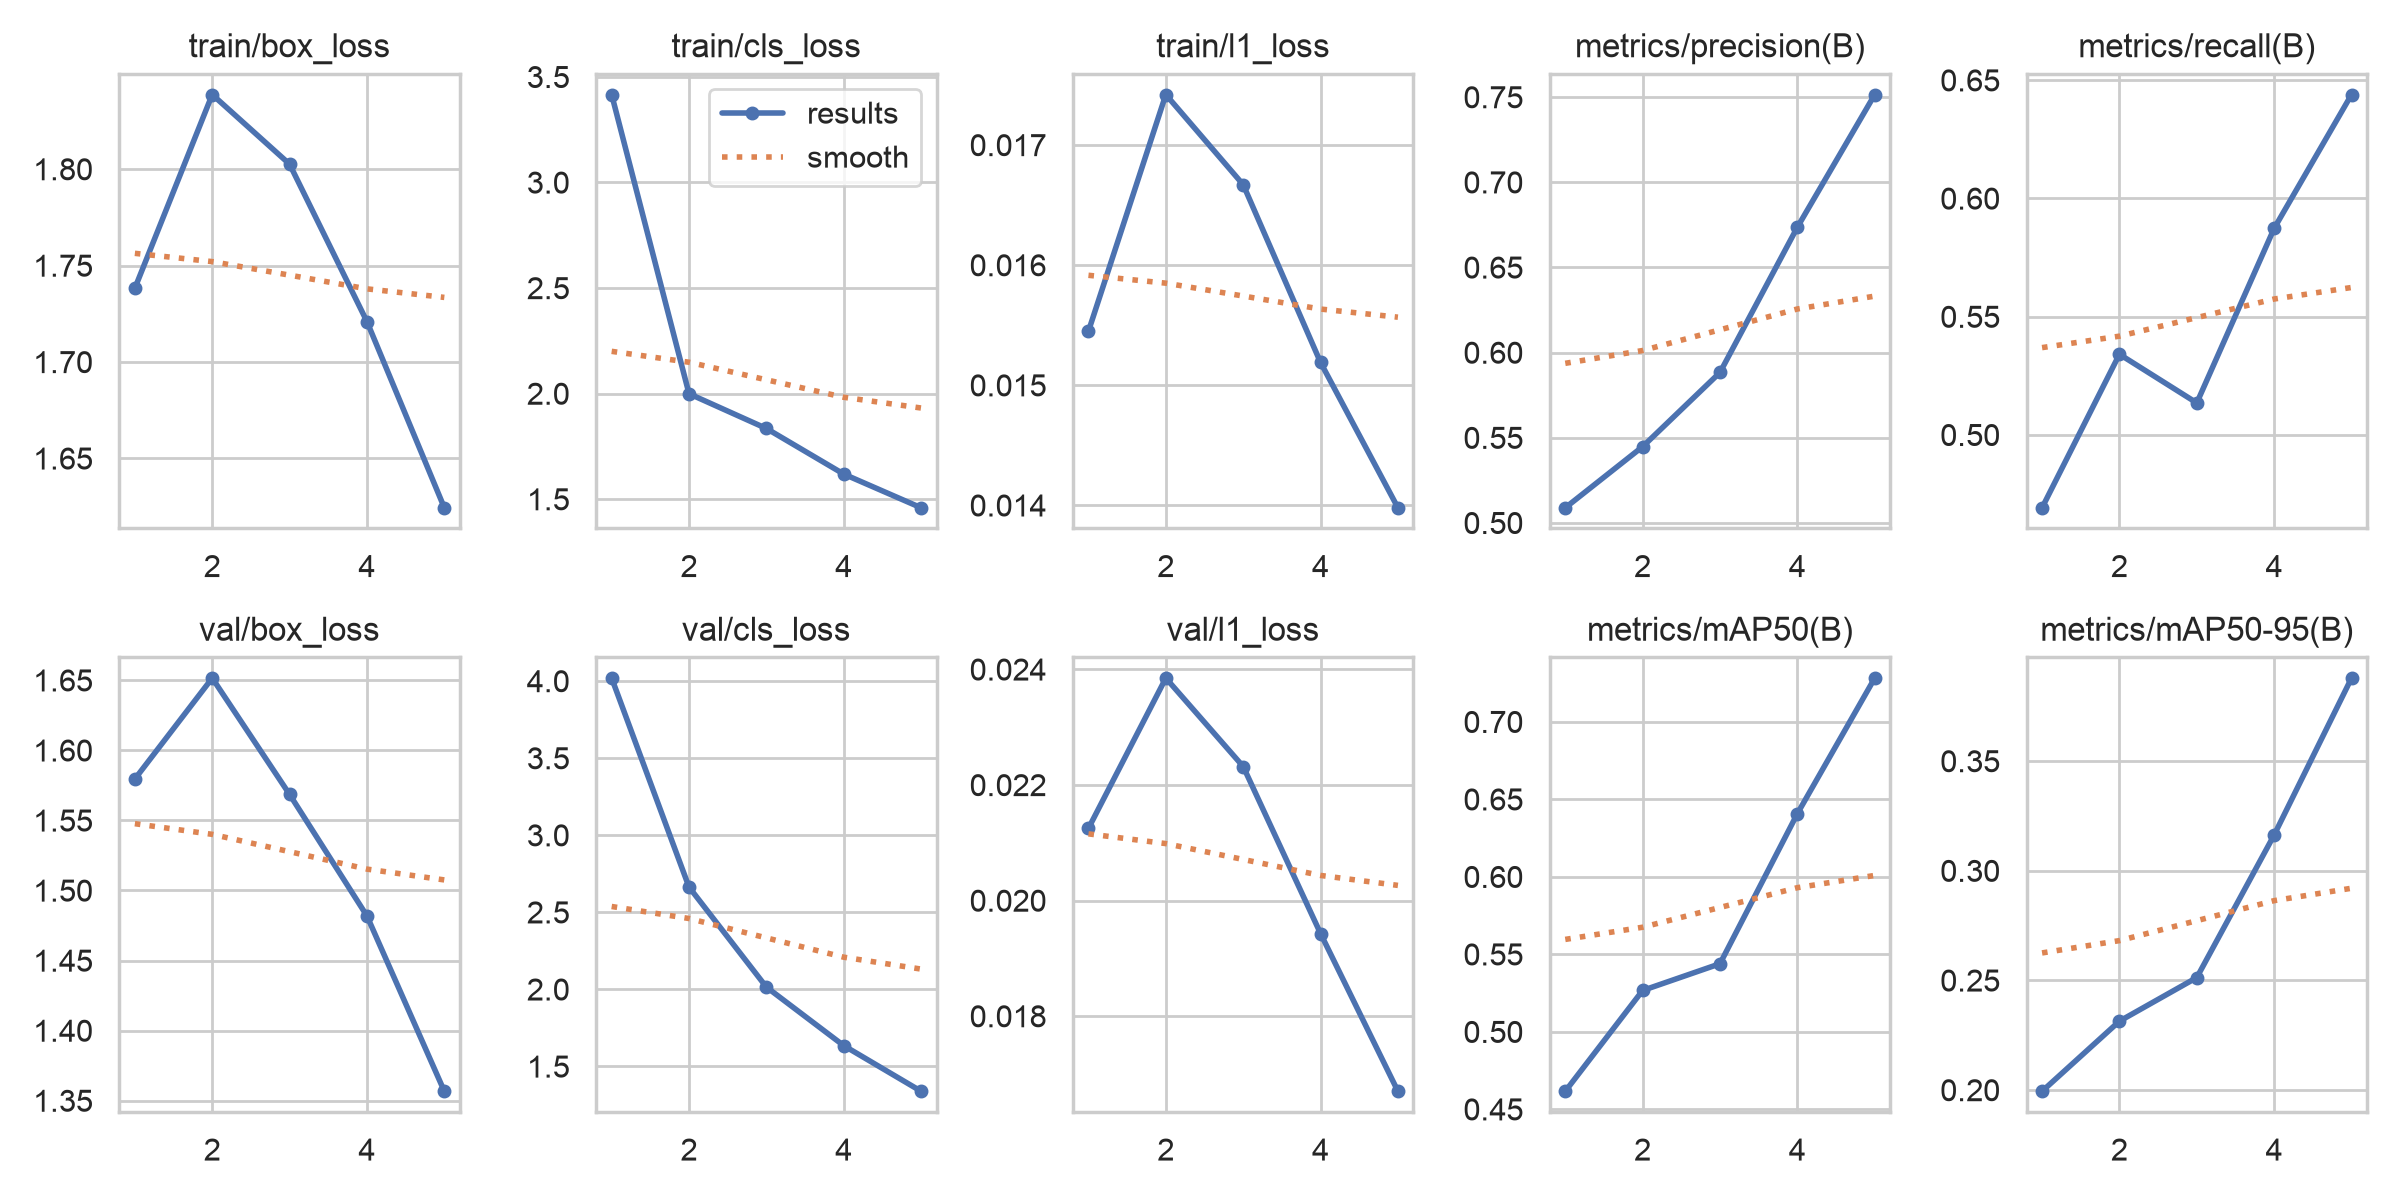

In [36]:
# Extract the core metrics from the results object
metrics = results.results_dict

print("📊 Baseline Validation Metrics:")
print(f"mAP@50:      {metrics['metrics/mAP50(B)']:.4f}")
print(f"mAP@50-95:   {metrics['metrics/mAP50-95(B)']:.4f}")
print(f"Precision:   {metrics['metrics/precision(B)']:.4f}")
print(f"Recall:      {metrics['metrics/recall(B)']:.4f}")

# Display the training summary plot automatically generated by YOLO
from IPython.display import Image
# Use the output directory returned by Ultralytics
results_path = os.path.join(str(results.save_dir), "results.png")

if os.path.exists(results_path):
    display(Image(filename=results_path))
else:
    print(f"Results plot not found: {results_path}")